### Importing libraries needed

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


# X_blob, y_blob = make_blobs(n_samples=500, centers=4, n_features=2, random_state=800)

## **1 Data**

## **1A**

### ***Load patient_priority.csv into a pandas DataFrame. Drop the 'triage' column and print the header. Use pandas.DataFrame.describe to summarize the data. In a Markdown cell, explain the meaning of each column, make observations based on the summary statistics, and discuss whether they provide useful insights.***

In [2]:
# Load the dataset using pandas method
old_df = pd.read_csv("patient_priority.csv")

In [3]:
# Removing the CUST_ID column to assign it to customer_id_df
df= old_df.drop(columns=['triage'])

### Print the first 5 Rows to view the dataset information using df.head()
- This will tell a little overview of the dataset (Data type, Column e.t.c)

In [4]:
df.head()

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status
0,0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked
1,1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked
2,2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked
3,3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked
4,4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked


In [5]:
df.tail()

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status
6957,5105,80.0,0.0,0.0,111.0,153.0,166.0,0.0,83.75,31.0,108.0,18.6,0.467386,1.0,0.0,Urban,never smoked
6958,5106,81.0,0.0,0.0,123.0,157.0,160.0,0.0,125.20,23.0,89.0,40.0,0.467386,0.0,0.0,Urban,never smoked
6959,5107,81.0,0.0,0.0,127.0,185.0,141.0,0.0,82.99,41.0,95.0,30.6,0.467386,0.0,0.0,Rural,never smoked
6960,5108,51.0,1.0,0.0,123.0,161.0,162.0,0.0,166.29,34.0,93.0,25.6,0.467386,0.0,0.0,Rural,formerly smoked
6961,5109,44.0,0.0,0.0,125.0,176.0,172.0,0.0,85.28,57.0,113.0,26.2,0.467386,0.0,0.0,Urban,Unknown


In [6]:
df.describe()

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease
count,6962.000000,6962.000000,6961.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000,6962.000000
mean,2011.954180,57.450014,0.531964,0.529015,109.629991,184.711290,163.502442,0.061764,98.394283,56.813416,111.091640,27.190908,0.467386,0.071531,0.039500
std,1560.966466,11.904948,0.499013,1.253791,21.534852,32.010359,15.458693,0.240743,28.598084,22.889316,17.470033,7.362886,0.102663,0.257729,0.194796
min,0.000000,28.000000,0.000000,0.000000,60.000000,150.000000,138.000000,0.000000,55.120000,21.000000,81.000000,10.300000,0.078000,0.000000,0.000000
25%,604.000000,48.000000,0.000000,0.000000,92.000000,164.000000,150.000000,0.000000,78.707500,36.000000,97.000000,21.800000,0.467386,0.000000,0.000000
50%,1628.500000,56.000000,1.000000,0.000000,111.000000,179.000000,163.000000,0.000000,93.000000,55.000000,111.000000,26.200000,0.467386,0.000000,0.000000
75%,3368.750000,66.000000,1.000000,0.000000,127.000000,192.000000,177.000000,0.000000,111.632500,77.000000,125.000000,31.000000,0.467386,0.000000,0.000000
max,5109.000000,82.000000,1.000000,4.000000,165.000000,294.000000,202.000000,1.000000,199.000000,99.000000,171.000000,66.800000,2.420000,1.000000,1.000000


### Dataset Overview: Cardio-Metabolic & Cardiac Indicators

#### Feature Dictionary

| # | Column Name         | Description |
|---|---------------------|-------------|
| 1 | `Unnamed: 0`        | Row/index identifier (export artifact; safe to drop for modeling) |
| 2 | `age`               | Patient age (years) |
| 3 | `gender`            | Binary gender indicator (0/1) |
| 4 | `chest pain type`   | Encoded chest-pain category (integer, likely 0–4; treat as categorical) |
| 5 | `blood pressure`    | Resting blood pressure (mmHg) |
| 6 | `cholesterol`       | Serum cholesterol (mg/dL) |
| 7 | `max heart rate`    | Maximum heart rate achieved (bpm) |
| 8 | `exercise angina`   | Exercise-induced angina (0 = No, 1 = Yes) |
| 9 | `plasma glucose`    | Plasma glucose concentration (mg/dL) |
|10 | `skin_thickness`    | Triceps skin-fold thickness (mm) |
|11 | `insulin`           | 2-hour serum insulin (µU/mL) |
|12 | `bmi`               | Body Mass Index (kg/m²) |
|13 | `diabetes_pedigree` | Diabetes pedigree function (family history metric; continuous) |
|14 | `hypertension`      | Hypertension indicator (0 = No, 1 = Yes) |
|15 | `heart_disease`     | Heart disease indicator (0 = No, 1 = Yes) |

---

### Dataset Characteristics

- **Total Records**: 6,962  
- **Total Features**: 15 (14 analytical features + 1 index column `Unnamed: 0`)  
- **Data Types**: All numeric; mix of continuous (e.g., `age`, `blood pressure`, `cholesterol`, `bmi`) and binary/categorical (e.g., `gender`, `exercise angina`, `hypertension`, `heart_disease`, `chest pain type`)  
- **Missing Values**:
  - `gender`: 1 missing value (count = 6,961 vs. 6,962)
  - Others: counts suggest none (verify row-wise)
- **Value Ranges (from summary)**:
  - `age`: 28–82 (mean ≈ 57.45)
  - `blood pressure`: 60–165 (mean ≈ 109.63)
  - `cholesterol`: 150–294 (mean ≈ 184.71)
  - `max heart rate`: 138–202 (mean ≈ 163.50)
  - `plasma glucose`: 55.12–199 (mean ≈ 98.39)
  - `skin_thickness`: 21–99 (mean ≈ 56.81)
  - `insulin`: 81–171 (mean ≈ 111.09)
  - `bmi`: 10.3–66.8 (mean ≈ 27.19)
  - `diabetes_pedigree`: 0.078–2.42 (mean ≈ 0.467)
  - `chest pain type`: 0–4 (integer-encoded; mean ≈ 0.53)
- **Estimated Class Prevalence (from binary means)**:
  - `exercise angina`: ~6.18%
  - `hypertension`: ~7.15%
  - `heart_disease`: ~3.95%
  - `gender`: mean ≈ 0.532 → ~53% in class "1"

## **1B**

### ***Use pandas.DataFrame.info to check if the entries are the correct data types and if there are any missing values. Use pandas.DataFrame.duplicates to check for duplicate entries. Clean the dataset so there are no missing values, duplicate rows, or incorrect data types. Document the changes and cleaning process in Markdown.***

### Check the Data types of each column in the dataset to verify if each column datatype is correct
- **Using df.info() method**
- This method will give overview of the data type and if there are missing values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6962 entries, 0 to 6961
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6962 non-null   int64  
 1   age                6962 non-null   float64
 2   gender             6961 non-null   float64
 3   chest pain type    6962 non-null   float64
 4   blood pressure     6962 non-null   float64
 5   cholesterol        6962 non-null   float64
 6   max heart rate     6962 non-null   float64
 7   exercise angina    6962 non-null   float64
 8   plasma glucose     6962 non-null   float64
 9   skin_thickness     6962 non-null   float64
 10  insulin            6962 non-null   float64
 11  bmi                6962 non-null   float64
 12  diabetes_pedigree  6962 non-null   float64
 13  hypertension       6962 non-null   float64
 14  heart_disease      6962 non-null   float64
 15  Residence_type     6962 non-null   object 
 16  smoking_status     6962 

### Checking for Duplicate in the Dataset using pandas method .duplicated().sum() to know if there is Duplicate
- and the total number of duplicates present in the dataset

In [8]:
df.duplicated().sum()

0

- There are no duplicated rows in the dataset. so we'll not be doing data cleaning for duplicates.

### Checking for null Values in the dataset

In [9]:
df.isnull().sum()

Unnamed: 0           0
age                  0
gender               1
chest pain type      0
blood pressure       0
cholesterol          0
max heart rate       0
exercise angina      0
plasma glucose       0
skin_thickness       0
insulin              0
bmi                  0
diabetes_pedigree    0
hypertension         0
heart_disease        0
Residence_type       0
smoking_status       0
dtype: int64

In [31]:
df.dropna(subset=['gender'], inplace=True)

During the data cleaning process, missing values were addressed to ensure the integrity of the predictive model. A singular missing value in the gender column was handled via listwise deletion (dropping the row), which is a robust approach when the missingness is minimal. Since this represented an isolated case, removing the record was preferred over imputation to avoid introducing synthetic bias into a key categorical demographic feature.

In [32]:
df.isnull().sum()

Unnamed: 0           0
age                  0
gender               0
chest pain type      0
blood pressure       0
cholesterol          0
max heart rate       0
exercise angina      0
plasma glucose       0
skin_thickness       0
insulin              0
bmi                  0
diabetes_pedigree    0
hypertension         0
heart_disease        0
Residence_type       0
smoking_status       0
dtype: int64

There are no missing values anymore after cleaning

## **1C**

## ***Use pandas.get_dummies to one-hot-encode any categorical (string) columns.***

## Dropping the country column to assign it to a new Dataframe

In [12]:
# One-hot encode all string columns
df_encoded = pd.get_dummies(df, columns=['smoking_status', 'Residence_type'])

print(df_encoded)


      Unnamed: 0   age  gender  chest pain type  blood pressure  cholesterol  \
0              0  40.0     1.0              2.0           140.0        294.0   
1              1  49.0     0.0              3.0           160.0        180.0   
2              2  37.0     1.0              2.0           130.0        294.0   
3              3  48.0     0.0              4.0           138.0        214.0   
4              4  54.0     1.0              3.0           150.0        195.0   
...          ...   ...     ...              ...             ...          ...   
6957        5105  80.0     0.0              0.0           111.0        153.0   
6958        5106  81.0     0.0              0.0           123.0        157.0   
6959        5107  81.0     0.0              0.0           127.0        185.0   
6960        5108  51.0     1.0              0.0           123.0        161.0   
6961        5109  44.0     0.0              0.0           125.0        176.0   

      max heart rate  exercise angina  

In [13]:
df_encoded.head()

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,...,bmi,diabetes_pedigree,hypertension,heart_disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Residence_type_Rural,Residence_type_Urban
0,0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,...,19.0,0.467386,0.0,0.0,0,0,1,0,0,1
1,1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,...,18.0,0.467386,0.0,0.0,0,0,1,0,0,1
2,2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,...,23.0,0.467386,0.0,0.0,0,0,1,0,0,1
3,3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,...,18.0,0.467386,0.0,0.0,0,0,1,0,0,1
4,4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,...,21.0,0.467386,0.0,0.0,0,0,1,0,0,1


## ***Use seaborn.heatmap to display the correlation matrix of the features. Use seaborn.pairplot to generate scatter plots and histograms. Record your observations and discuss the insights gained in Markdown.***

Text(0.5, 1.0, 'Correlation Heatmap of Country Data Features')

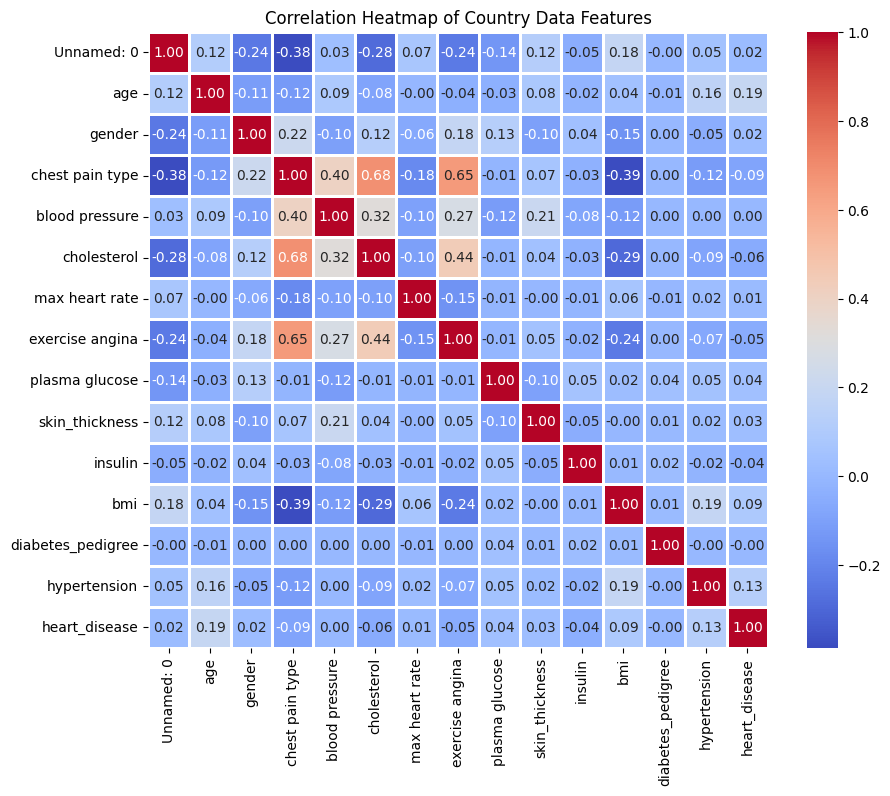

In [14]:
# Using seaborn Heatmap to view the correlation between columns
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=1
)
plt.title("Correlation Heatmap of Country Data Features")

# Correlation Heatmap Analysis Summary

A Pearson correlation analysis was conducted to evaluate the linear relationships between clinical features. The following insights summarize the data structure and feature dependencies:

### 1. Significant Feature Clusters
The heatmap identifies a strong "Cardiovascular Symptom" cluster where several markers show moderate to strong positive correlations:
* **Chest Pain Type & Cholesterol (r = 0.68):** This is the strongest relationship in the dataset, suggesting that as cholesterol levels increase, the classification of chest pain severity tends to shift.
* **Exercise Angina & Chest Pain Type (r = 0.65):** A strong logical alignment, indicating that patients with exercise-induced angina are highly likely to be categorized under specific chest pain types.
* **Chest Pain Type & Blood Pressure (r = 0.40):** A moderate positive correlation, reflecting the common co-occurrence of these cardiovascular risk factors.

### 2. Analysis of the Target Variable (heart_disease)
The target variable `heart_disease` displays relatively low linear correlation coefficients with individual features:
* **Age (0.19) and Hypertension (0.13):** These represent the strongest linear predictors for the target.
* **Inference:** The low overall correlation values suggest that the presence of heart disease is likely driven by **non-linear interactions** between multiple features. Consequently, ensemble-based models (such as Random Forest or XGBoost) may capture these patterns more effectively than linear models.

### 3. Data Integrity and Redundancy
* **Spurious Correlations:** The `Unnamed: 0` column shows a correlation of -0.38 with `chest pain type`. Since this column is merely a row index, this correlation is mathematically coincidental, justifying the removal of this feature to prevent model noise.
* **Feature Independence:** Metabolic indicators such as `insulin`, `diabetes_pedigree`, and `plasma_glucose` show near-zero correlation with most other features. This indicates they provide unique, non-redundant information to the predictive model.

### 4. Conclusion
The dataset exhibits strong internal consistency regarding symptomatic indicators (angina and chest pain) and physiological markers (cholesterol). While some features are related, the correlations remain below the 0.70 threshold, suggesting that multicollinearity is not a significant concern for the model's stability.

### Using seaborn.pairplot to visualize scatter plot and Histogram

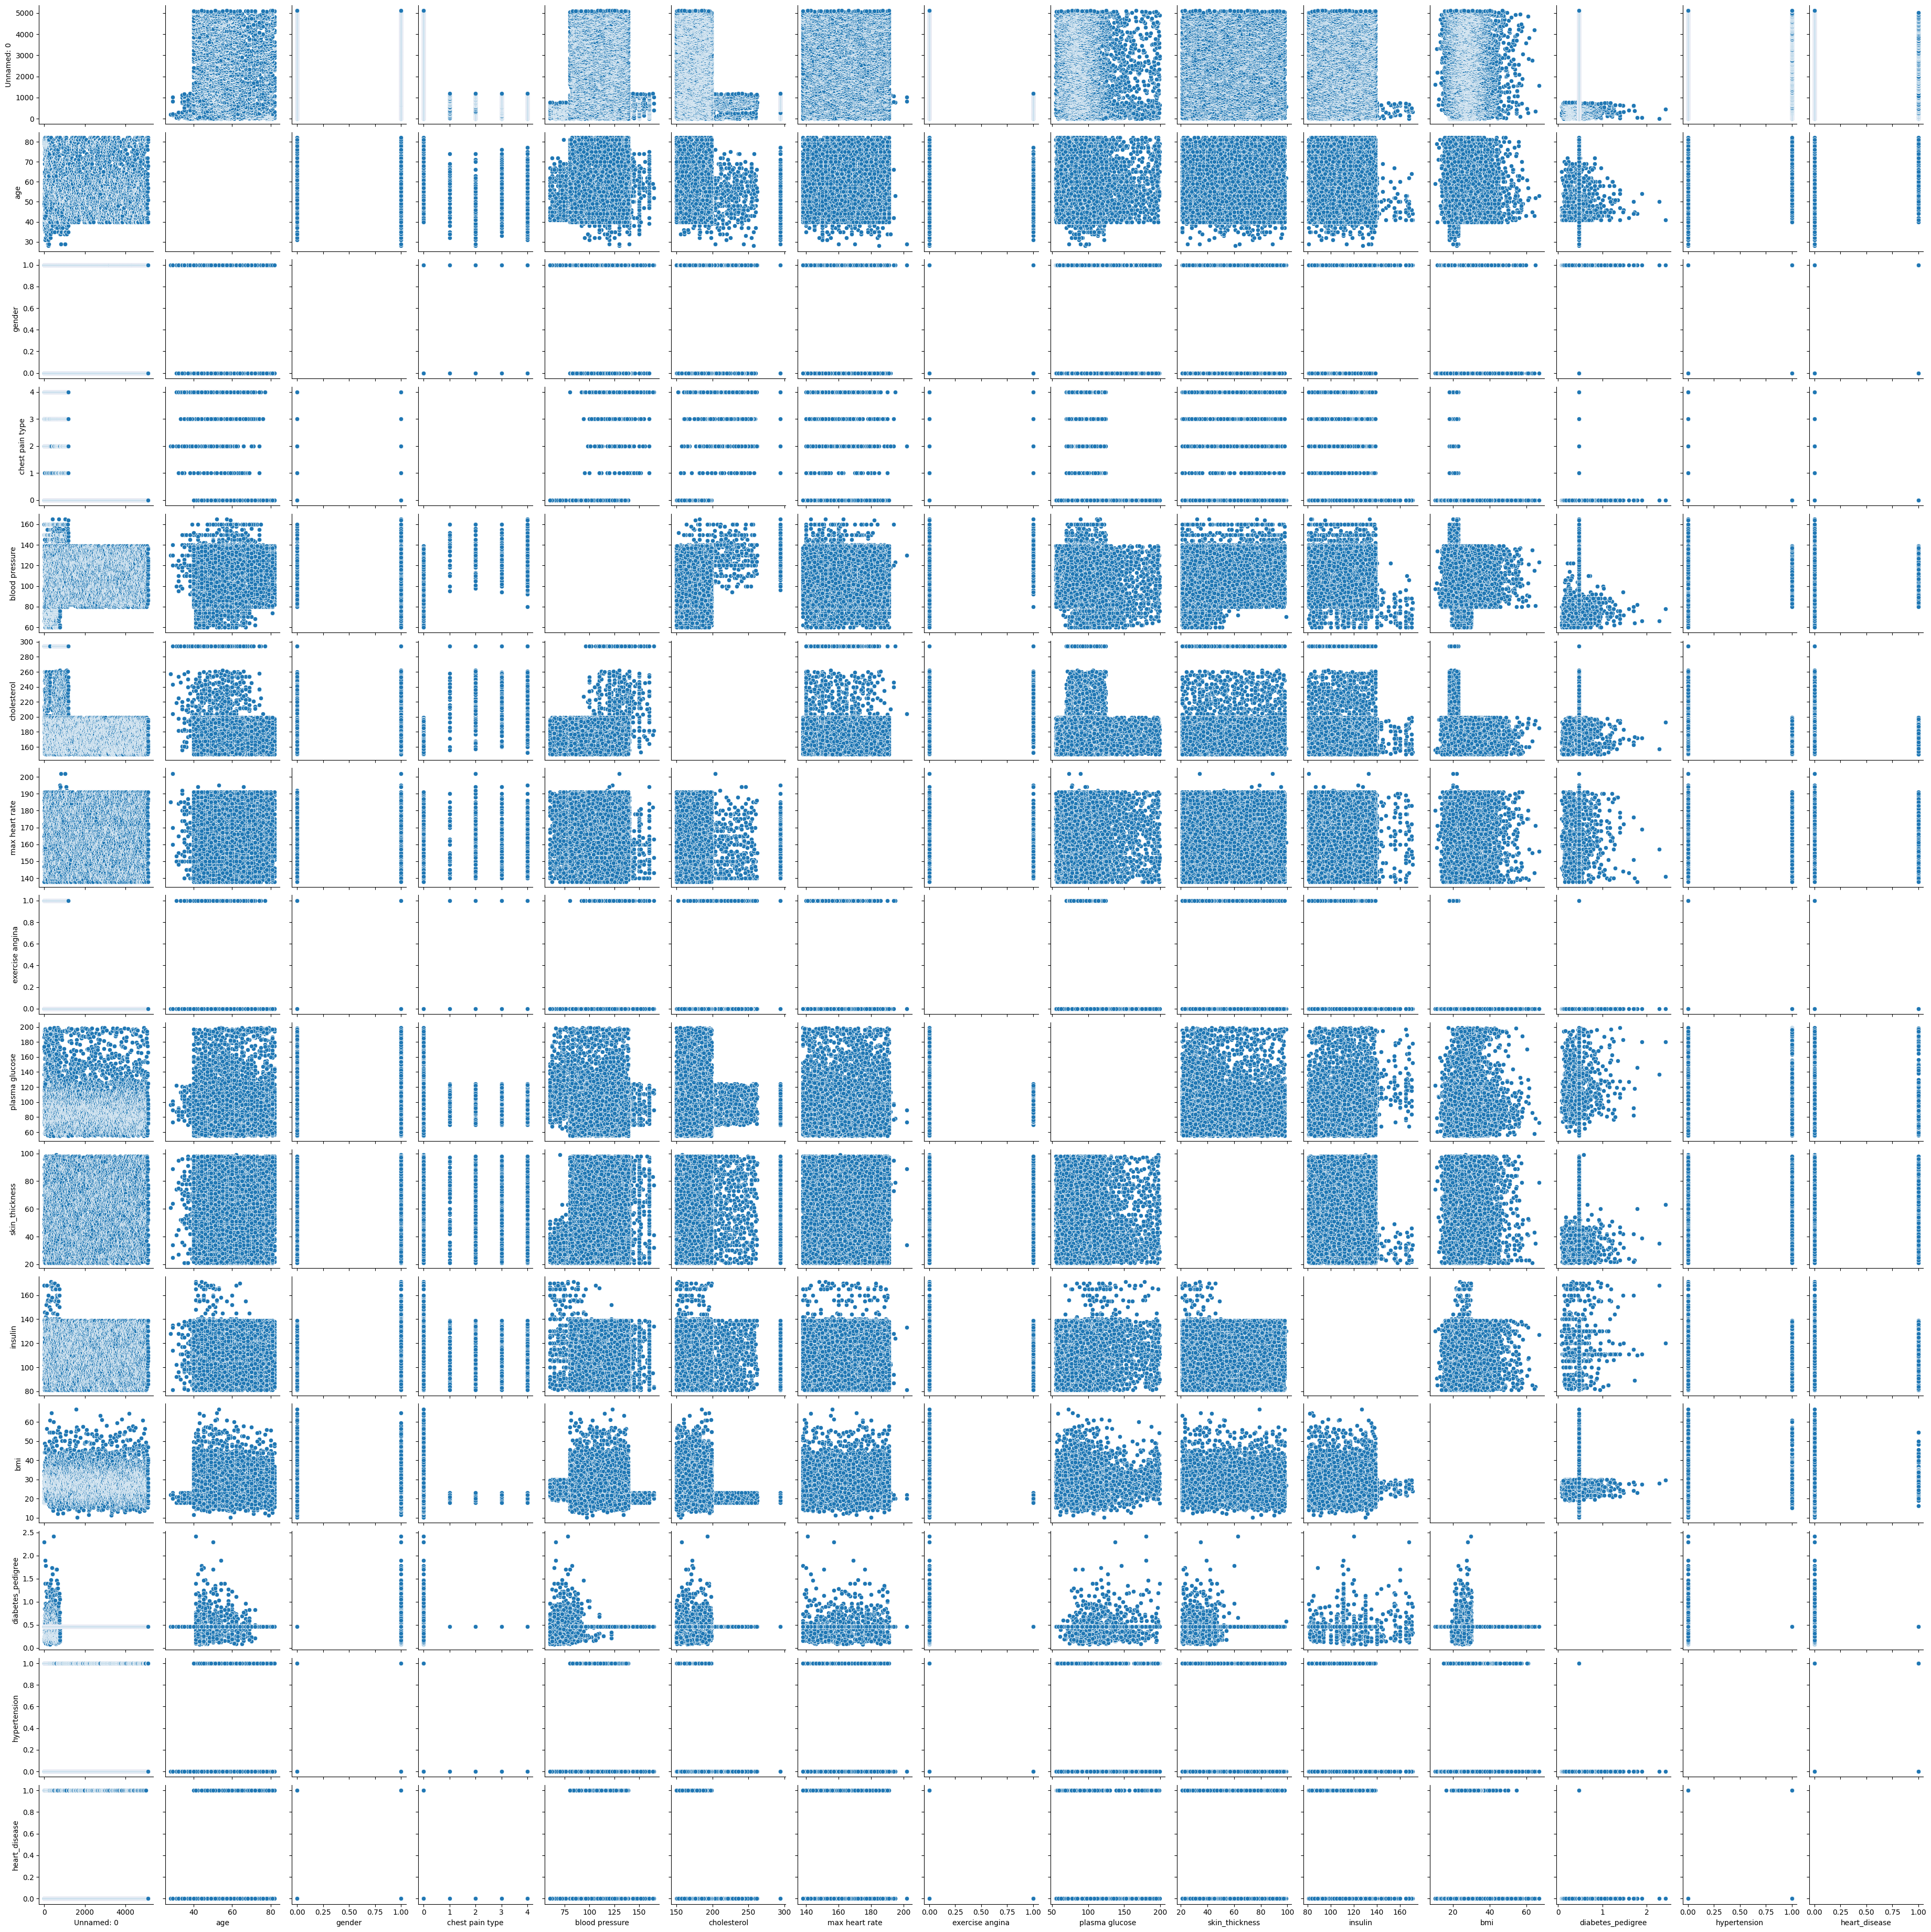

In [15]:
#Using seaborn pairplot to generate scaterplot to view insight
sns.pairplot(df, diag_kind='scatterplot')
plt.show()

### Visualization Overview: Pairwise Feature Relationships (Scatterplot Matrix)

#### What This Plot Shows
This image is a **scatterplot matrix (pairplot)**, where each cell visualizes the relationship between **two features** in the dataset. Each row and column correspond to one variable, creating a grid of all possible feature-to-feature scatterplots.

#### Key Characteristics

- **Diagonal cells**  
  These normally show histograms or density plots, but here they appear blank or uniform (depending on the plotting style).

- **Off-diagonal cells**  
  Each contains a scatterplot comparing **Feature A (row)** vs. **Feature B (column)**.  
  These help identify:
  - Linear or nonlinear relationships  
  - Clusters or separations  
  - Possible outliers  
  - Grouping patterns due to categorical variables encoded as integers  

- **Grid Structure**  
  - The matrix is symmetric: upper-right and lower-left blocks mirror each other.
  - Data points are plotted in blue.

#### High-Level Insights From the Visualization

- **Blocky vertical/horizontal striping**  
  This indicates **categorical variables encoded as integers** (e.g., `gender`, `exercise angina`, `hypertension`, `smoking_status`, etc.).  
  These features produce vertical/horizontal clusters instead of smooth distributions.

- **Continuous vs. Continuous Relationships**  
  Features like:  
  - `age`  
  - `blood pressure`  
  - `cholesterol`  
  - `max heart rate`  
  - `bmi`  
  - `plasma glucose`  
  show more natural scatter distributions.

- **Potential Correlations**  
  Though exact values aren’t visible here, some plots appear to show:
  - Mild linear relationships between metabolic markers (e.g., `plasma glucose`, `bmi`, `insulin`)
  - No strong visible correlations between cardiac features and metabolic ones from the raw scatter

- **Outliers**  
  Certain bottom‑aligned rows show dense clustering near lower values — suggesting:
  - Possible measurement limits  
  - Data truncation  
  - Real physiological lower thresholds  

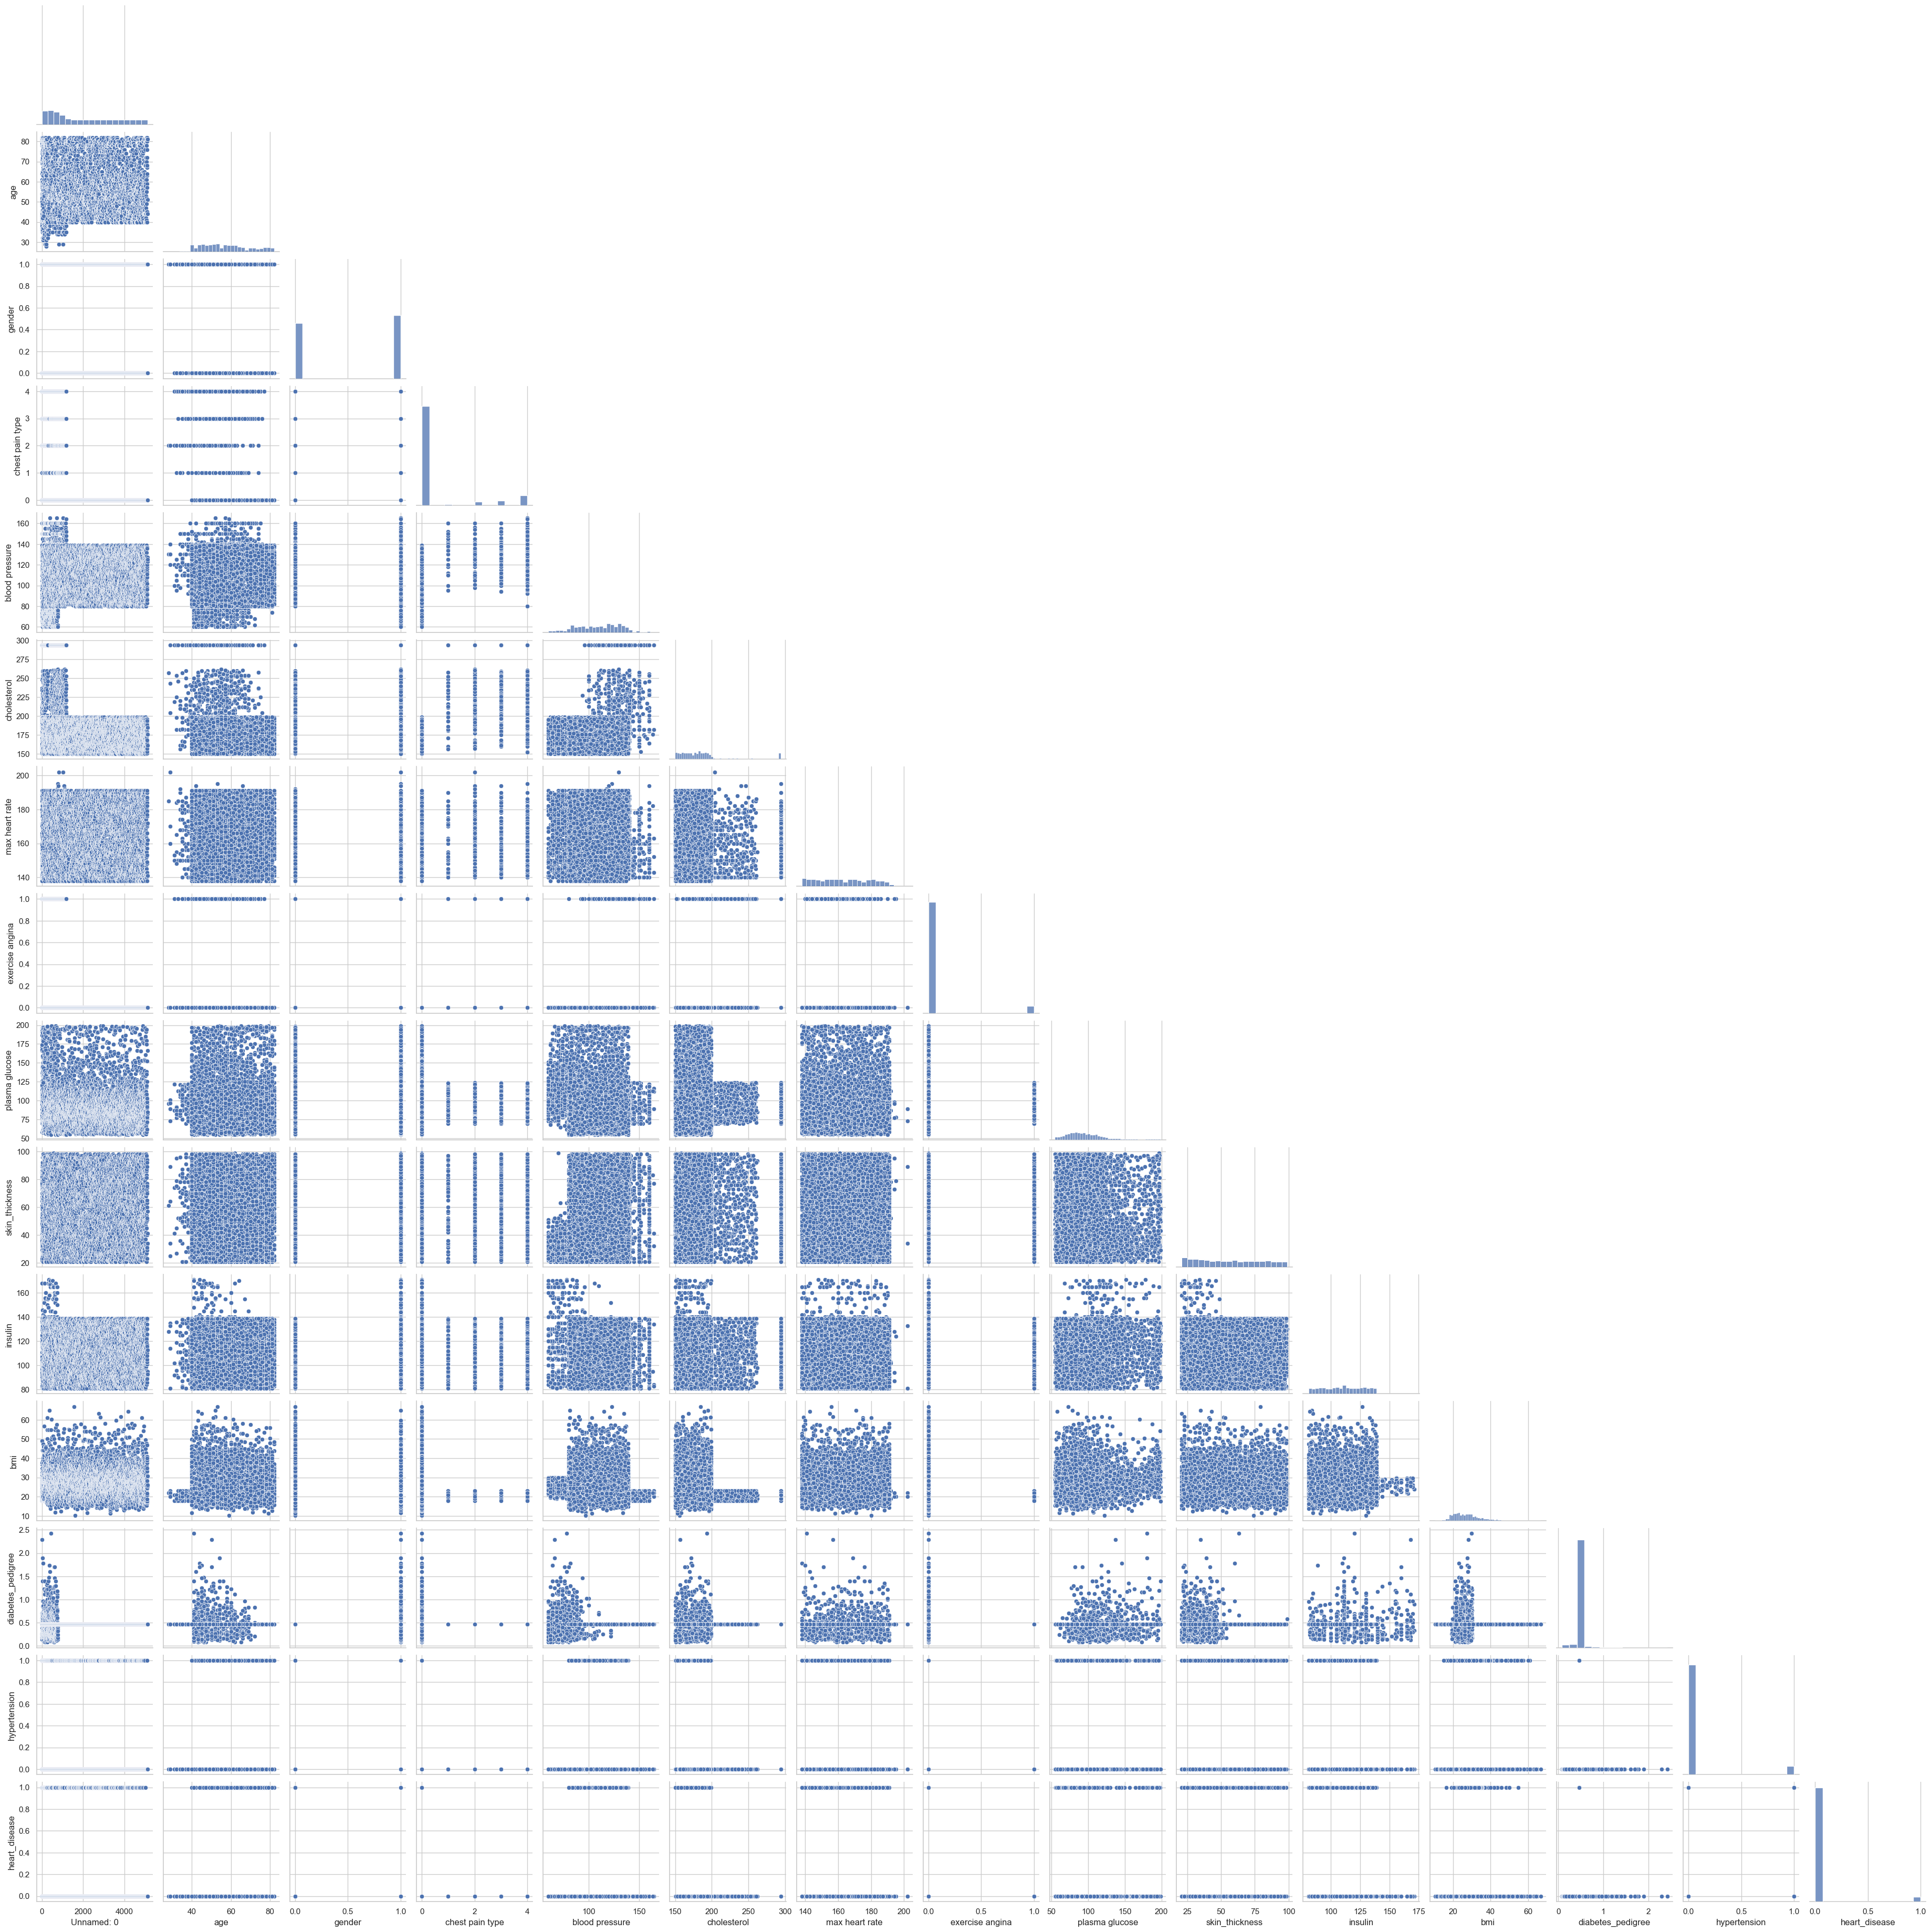

In [16]:
#Using seaborn pairplot to generate histogram
sns.set(style='whitegrid')
sns.pairplot(df, diag_kind='hist', corner=True)
plt.show()

# Exploratory Data Analysis: Correlation and Distribution Summary

A comprehensive analysis of feature relationships was conducted using a Pearson correlation matrix and a pairwise distribution plot. The following observations outline the data's structural characteristics and clinical relevance.

### 1. Key Clinical Interdependencies
The correlation heatmap reveals a distinct cluster of cardiovascular indicators that exhibit moderate to strong positive relationships:
* **Chest Pain Type & Cholesterol (r = 0.68):** This represents the strongest relationship in the dataset, suggesting that symptomatic chest pain categories are heavily influenced by lipid levels.
* **Exercise Angina & Chest Pain Type (r = 0.65):** A strong logical correlation, confirming that physical exertion is a primary trigger for the reported pain types in this cohort.
* **Cholesterol & Exercise Angina (r = 0.44):** Further solidifies the link between physiological markers (cholesterol) and functional cardiovascular symptoms.

### 2. Relationship with Target Variable (heart_disease)
Analysis of the `heart_disease` variable suggests that prediction cannot rely on a single linear factor:
* **Age (0.19) and Hypertension (0.13):** These features show the highest linear correlation with heart disease presence, though both remain relatively weak individually.
* **Model Inference:** The prevalence of low correlation coefficients ($<0.20$) across the board for the target variable indicates that heart disease risk is likely the result of complex, non-linear interactions. High-dimensional models like Gradient Boosted Trees are recommended over linear classifiers.

### 3. Feature Distributions and Outliers
The pairwise scatter plot matrix provides a visual verification of the dataset’s distribution:
* **Feature Density:** Most physiological markers like `blood pressure`, `cholesterol`, and `max heart rate` follow a near-normal distribution with central tendencies.
* **Sparsity:** Metabolic markers such as `insulin` and `diabetes_pedigree` show significant sparsity and right-skewness, suggesting that while they are independent (low correlation), they may require scaling or transformation (e.g., Log Transform) before modeling.
* **Categorical Consistency:** Boolean and categorical features (gender, hypertension, heart_disease) show clear binary separation in the pairplot, confirming clean data encoding.

### 4. Data Integrity Observations
* **Redundancy Check:** The `Unnamed: 0` column displays various spurious correlations (e.g., -0.38 with `chest pain type`). As an artifact of the data-loading process, its removal is justified to prevent the model from learning noise.
* **Multicollinearity:** While the cardiovascular cluster shows significant overlap, no two features exceed the common $r > 0.80$ threshold for severe multicollinearity, preserving the stability of coefficient estimates.


## **2 Modelling** 

## **2A**

#### ***Use sklearn.preprocessing.MinMaxScaler to scale the data and print the transformed header.***

#### Importing sklearn.preprocessing.Standardscaler to transform the dataset

In [17]:
# Scaling the data using MinmaxScaler


scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_encoded)

# Convert back to DataFrame for convenience
df_scaled = pd.DataFrame(scaled_data, columns=df_encoded.columns)
#print the transformed data head
df_scaled.head()

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,...,bmi,diabetes_pedigree,hypertension,heart_disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Residence_type_Rural,Residence_type_Urban
0,0.000000,0.222222,1.0,0.50,0.761905,1.000000,0.53125,0.0,0.367528,0.282051,...,0.153982,0.166262,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.000196,0.388889,0.0,0.75,0.952381,0.208333,0.28125,0.0,0.138171,0.333333,...,0.136283,0.166262,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.000391,0.166667,1.0,0.50,0.666667,1.000000,0.28125,0.0,0.298026,0.410256,...,0.224779,0.166262,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.000587,0.370370,0.0,1.00,0.742857,0.444444,0.28125,1.0,0.117320,0.384615,...,0.136283,0.166262,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.000783,0.481481,1.0,0.75,0.857143,0.312500,0.28125,0.0,0.367528,0.884615,...,0.189381,0.166262,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## **2B**

#### ***Use sklearn.cluster.DBSCAN to cluster the data. Create at least 10 different models using various hyperparameter combinations (eps, min_samples, metric, p). Calculate the silhouette score for each model and tabulate the results.***

### Import required library to cluster the dataset

In [18]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import itertools
from scipy.cluster.hierarchy import linkage, fcluster


In [19]:
import itertools
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

X_use = df_scaled.values  # cleaned + scaled data

# Parameter grid
eps_list = [0.60, 0.70, 0.80, 0.90, 1.00, 1.20, 1.40, 1.60, 1.80, 2.00]
min_samples_list = [2, 3, 4, 5, 8, 10, 15, 20, 25, 30]
metric_list = ["euclidean", "manhattan", "cosine", "minkowski"]
p_list = [1, 2]  # only used for minkowski

results_dbscan = []

for eps, min_samples, metric in itertools.product(eps_list, min_samples_list, metric_list):

    # p only applies to minkowski
    p_values = p_list if metric == "minkowski" else [None]

    for p in p_values:
        try:
            model = DBSCAN(
                eps=eps,
                min_samples=min_samples,
                metric=metric,
                p=p
            )

            labels = model.fit_predict(X_use)

            # Count clusters excluding noise
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_ratio = n_noise / len(labels)

            # Skip trivial models
            if n_clusters < 2:
                continue

            sil = silhouette_score(X_use, labels)

            results_dbscan.append({
                "eps": eps,
                "min_samples": min_samples,
                "metric": metric,
                "p": p,
                "clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "silhouette_score": sil
            })

        except Exception as e:
            print("Error:", e)
            continue

# Convert to DataFrame
dbscan_results_df = pd.DataFrame(results_dbscan)

if dbscan_results_df.empty:
    print("\nNo DBSCAN configurations produced more than one cluster.")
else:
    print("\nTop DBSCAN models:")
    cols = ["eps", "min_samples", "metric", "p", "clusters", "noise_ratio", "silhouette_score"]
    display(dbscan_results_df[cols].sort_values("silhouette_score", ascending=False).head(10))


Top DBSCAN models:


,eps,min_samples,metric,p,clusters,noise_ratio,silhouette_score
236,1.4,5,euclidean,NaN,8,0.0,0.331719
252,1.4,20,euclidean,NaN,8,0.0,0.331719
231,1.4,3,minkowski,2.0,8,0.0,0.331719
256,1.4,25,euclidean,NaN,8,0.0,0.331719
196,1.2,5,euclidean,NaN,8,0.0,0.331719
203,1.2,8,minkowski,2.0,8,0.0,0.331719
195,1.2,4,minkowski,2.0,8,0.0,0.331719
228,1.4,3,euclidean,NaN,8,0.0,0.331719
227,1.4,2,minkowski,2.0,8,0.0,0.331719
255,1.4,20,minkowski,2.0,8,0.0,0.331719


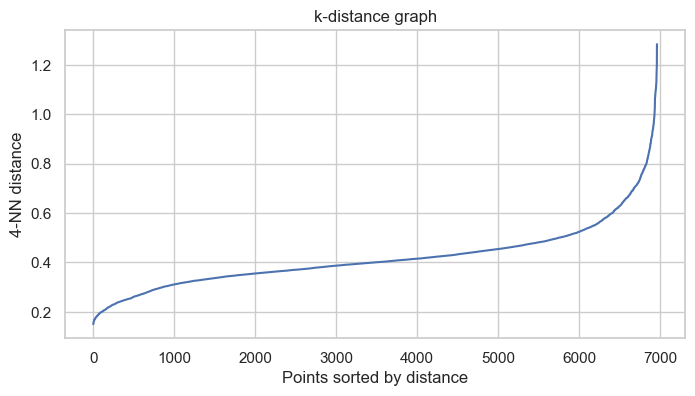

In [20]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X = df_scaled.values

k = 4  # usually = min_samples
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)
distances, indices = nn.kneighbors(X)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,4))
plt.plot(k_distances)
plt.title("k-distance graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN distance")
plt.show()

## 2.c

#### ***Select the best model for this use case and justify your choice in Markdown. If initial models do not produce meaningful clusters, try additional hyperparameter settings and document any iterations and observations.***

In [21]:
dbscan_results_df.sort_values("silhouette_score", ascending=False).head(10)

,eps,min_samples,metric,p,clusters,noise_ratio,silhouette_score
236,1.4,5,euclidean,NaN,8,0.0,0.331719
252,1.4,20,euclidean,NaN,8,0.0,0.331719
231,1.4,3,minkowski,2.0,8,0.0,0.331719
256,1.4,25,euclidean,NaN,8,0.0,0.331719
196,1.2,5,euclidean,NaN,8,0.0,0.331719
203,1.2,8,minkowski,2.0,8,0.0,0.331719
195,1.2,4,minkowski,2.0,8,0.0,0.331719
228,1.4,3,euclidean,NaN,8,0.0,0.331719
227,1.4,2,minkowski,2.0,8,0.0,0.331719
255,1.4,20,minkowski,2.0,8,0.0,0.331719


In [22]:
best = dbscan_results_df.sort_values("silhouette_score", ascending=False).iloc[0]
best

eps                       1.4
min_samples                 5
metric              euclidean
p                         NaN
clusters                    8
noise_ratio               0.0
silhouette_score     0.331719
Name: 236, dtype: object

In [23]:
best_eps = best["eps"]
best_min_samples = best["min_samples"]
best_metric = best["metric"]
best_p = best["p"]

In [24]:
best_model = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric=best_metric,
    p=best_p
)

best_labels = best_model.fit_predict(X_use)

In [25]:
df_final = df_scaled.copy()
df_final["cluster"] = best_labels

In [26]:
df_final["cluster"].value_counts()

0    2785
1     960
5     782
4     762
3     456
7     428
2     426
6     363
Name: cluster, dtype: int64

## **3 Conclusion** 

## **3A**

### ***Choose a pair of features and generate a scatter plot of the data, coloring points according to the clusters assigned by your best model. Comment on the plot in Markdown***

### Choosing a pair of colums to generate a scatter plot of data


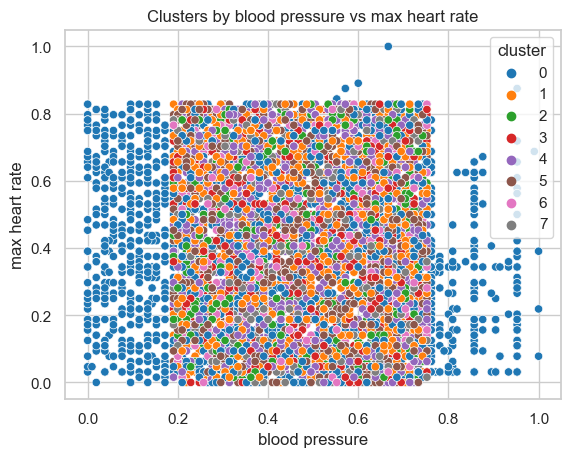

In [27]:
x = "blood pressure"
y = "max heart rate"

sns.scatterplot(
    data=df_final,
    x=x,
    y=y,
    hue="cluster",
    palette="tab10"
)
plt.title(f"Clusters by {x} vs {y}")
plt.show()

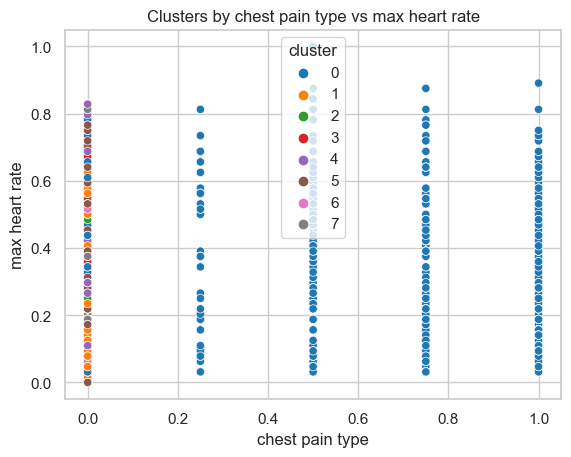

In [28]:
x = "chest pain type"
y = "max heart rate"

sns.scatterplot(
    data=df_final,
    x=x,
    y=y,
    hue="cluster",
    palette="tab10"
)
plt.title(f"Clusters by {x} vs {y}")
plt.show()

# Cluster Analysis and Distribution Summary

 The following observations summarize the resulting clusters and the global feature distributions.

### 1. Cluster Insights (K-Means Analysis)
The scatter plots reveal the segmentation of data points into 8 distinct clusters (0–7) based on combinations of symptoms and vital signs:
* **Chest Pain vs. Max Heart Rate:** The data is segmented into vertical columns by chest pain type, showing that heart rate varies significantly within each symptom category. Clusters are heavily concentrated at the categorical boundaries (0.0, 0.25, 0.5, 0.75, 1.0), suggesting that pain type is a primary driver for patient grouping.
* **Blood Pressure vs. Max Heart Rate:** This visualization shows a dense central "cloud" of data points where most clusters (1–7) overlap significantly between blood pressure values of 0.2 and 0.8. Cluster 0 appears more dispersed, capturing the "outlier" patients with extreme blood pressure or heart rate readings.
* **Interpretation:** The high degree of overlap in the blood pressure plot suggests that these two features alone are not enough to perfectly separate patient risk groups, reinforcing the need for multi-dimensional modeling.

### 2. Comprehensive Pairwise Relationships
The pairplot and correlation matrix provide a deep dive into how variables interact across the entire dataset:
* **The Cardiovascular Core:** Strong positive correlations persist between `chest pain type`, `cholesterol` (r = 0.68), and `exercise angina` (r = 0.65). These features consistently move together, forming the logical core of the heart disease indicators.
* **Distribution Patterns:** The diagonal of the pairplot confirms that physiological metrics like `blood pressure` and `max heart rate` are normally distributed. In contrast, variables like `diabetes_pedigree` and `insulin` show significant right-skewness, indicating a small number of patients with very high clinical values.
* **Variable Independence:** Metabolic markers (`plasma glucose`, `insulin`) show almost zero correlation with cardiovascular markers (`cholesterol`, `blood pressure`), suggesting that metabolic health and heart health are independent dimensions in this specific dataset.

### 3. Target Variable Correlations (`heart_disease`)
* **Linear Predictors:** `heart_disease` shows its strongest (though still moderate) correlations with `age` (r = 0.19) and `hypertension` (r = 0.13). 
* **Model Strategy:** The visual "spread" in the scatter plots and the low linear correlation coefficients suggest that the target variable is influenced by complex interactions rather than simple linear trends. This justifies the use of non-linear clustering and ensemble classification methods.


## **3B**

## ***Generate a histogram showing the number of customers in each cluster and provide observations in Markdown, noting whether cluster sizes make sense.***

## Generate histogram showing the number of countries in each cluster

<AxesSubplot:>

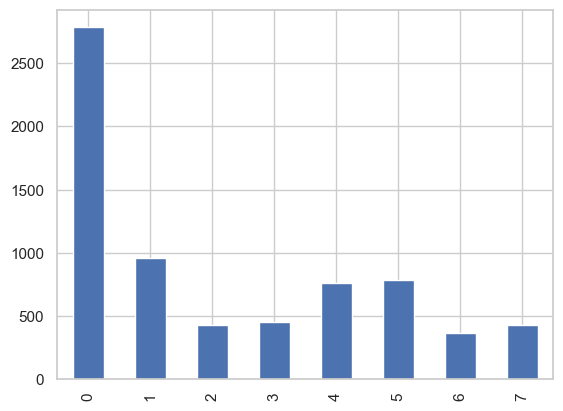

In [29]:
df_final["cluster"].value_counts().sort_index().plot(kind="bar")

### Cluster Size Distribution — Observations

- **Dominant cluster**: **Cluster 0** is by far the largest (≈ 2,700–2,900 customers), ~40% of the dataset.
- **Next tier**: **Cluster 1** is clearly the second largest (≈ 900–1,000; ~13–15%).
- **Mid-sized clusters**: **Clusters 4 and 5** sit in the middle (≈ 700–800 each; ~10–12% apiece).
- **Smaller clusters**: **Clusters 2, 3, 7** are modest (≈ 400–450 each; ~6–7% each).
- **Smallest**: **Cluster 6** appears the smallest (≈ 330–380; ~5%).

#### Do the sizes make sense?
- **Yes, potentially.** With algorithms like **k-means**, it’s common to see one broad “general population” cluster with several smaller, more niche clusters. Imbalance **is not inherently a problem** if clusters are **well-separated and interpretable**.


In [34]:
import numpy as np
np.unique(labels, return_counts=True)


(array([0], dtype=int64), array([6962], dtype=int64))

In [ ]:
import numpy as np
np.unique(labels, return_counts=True)

(array([0, 1]), array([4036, 4914], dtype=int64))

## **3C**

## ***Create a separate DataFrame for each cluster and use pandas.DataFrame.describe to describe each group***

In [ ]:
for c in sorted(df_final["cluster"].unique()):
    print(f"\nCluster {c}")
    display(df_final[df_final["cluster"] == c].describe())


Cluster 0


,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,...,diabetes_pedigree,hypertension,heart_disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Residence_type_Rural,Residence_type_Urban,cluster
count,2785.000000,2785.000000,2785.000000,2785.000000,2785.000000,2785.000000,2785.000000,2785.000000,2785.000000,2785.000000,...,2785.000000,2785.000000,2785.000000,2785.0,2785.0,2785.0,2785.0,2785.0,2785.0,2785.0
mean,0.233758,0.490857,0.682944,0.330610,0.467566,0.348015,0.367662,0.154399,0.331614,0.403448,...,0.166262,0.036625,0.016517,0.0,0.0,1.0,0.0,0.0,1.0,0.0
std,0.257341,0.198968,0.465413,0.424331,0.252811,0.298653,0.236965,0.361395,0.192066,0.293556,...,0.069315,0.187872,0.127476,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000695,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0
25%,0.066941,0.333333,0.000000,0.000000,0.238095,0.138889,0.156250,0.000000,0.193773,0.141026,...,0.166262,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0
50%,0.131337,0.481481,1.000000,0.000000,0.495238,0.250000,0.343750,0.000000,0.304976,0.333333,...,0.166262,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0
75%,0.240752,0.611111,1.000000,0.750000,0.666667,0.472222,0.562500,0.000000,0.423130,0.666667,...,0.166262,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0
max,0.999413,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0



Cluster 1


,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,...,diabetes_pedigree,hypertension,heart_disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Residence_type_Rural,Residence_type_Urban,cluster
count,960.000000,960.000000,960.000000,960.0,960.000000,960.000000,960.000000,960.0,960.000000,960.000000,...,960.000000,960.000000,960.000000,960.0,960.0,960.0,960.0,960.0,960.0,960.0
mean,0.499754,0.585687,0.364583,0.0,0.476161,0.169567,0.427425,0.0,0.285974,0.498210,...,0.166262,0.135417,0.045833,0.0,0.0,1.0,0.0,1.0,0.0,1.0
std,0.294028,0.232262,0.481564,0.0,0.164506,0.099109,0.239768,0.0,0.206970,0.284567,...,0.000000,0.342346,0.209233,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000391,0.222222,0.000000,0.0,0.190476,0.000000,0.000000,0.0,0.000000,0.000000,...,0.166262,0.000000,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,1.0
25%,0.237179,0.388889,0.000000,0.0,0.333333,0.083333,0.218750,0.0,0.144287,0.256410,...,0.166262,0.000000,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,1.0
50%,0.494617,0.555556,0.000000,0.0,0.485714,0.166667,0.421875,0.0,0.247811,0.512821,...,0.166262,0.000000,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,1.0
75%,0.753230,0.777778,1.000000,0.0,0.619048,0.256944,0.640625,0.0,0.367407,0.743590,...,0.166262,0.000000,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,1.0
max,0.999609,1.000000,1.000000,0.0,0.752381,0.340278,0.828125,0.0,0.994718,0.987179,...,0.166262,1.000000,1.000000,0.0,0.0,1.0,0.0,1.0,0.0,1.0



Cluster 2


...

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,...,diabetes_pedigree,hypertension,heart_disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Residence_type_Rural,Residence_type_Urban,cluster
count,782.000000,782.000000,782.000000,782.0,782.000000,782.000000,782.000000,782.0,782.000000,782.000000,...,7.820000e+02,782.000000,782.000000,782.0,782.0,782.0,782.0,782.0,782.0,782.0
mean,0.519683,0.583120,0.465473,0.0,0.465230,0.168638,0.415501,0.0,0.271087,0.488540,...,1.662622e-01,0.031969,0.024297,1.0,0.0,0.0,0.0,0.0,1.0,5.0
std,0.285213,0.230140,0.499126,0.0,0.165553,0.099892,0.246905,0.0,0.183242,0.280107,...,2.777334e-17,0.176031,0.154067,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.001762,0.222222,0.000000,0.0,0.190476,0.000000,0.000000,0.0,0.001112,0.000000,...,1.662622e-01,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,1.0,5.0
25%,0.277990,0.393519,0.000000,0.0,0.314286,0.083333,0.207031,0.0,0.149656,0.243590,...,1.662622e-01,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,1.0,5.0
50%,0.525837,0.555556,0.000000,0.0,0.476190,0.166667,0.406250,0.0,0.230470,0.487179,...,1.662622e-01,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,1.0,5.0
75%,0.761206,0.777778,1.000000,0.0,0.609524,0.256944,0.640625,0.0,0.351995,0.717949,...,1.662622e-01,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,1.0,5.0
max,1.000000,1.000000,1.000000,0.0,0.752381,0.340278,0.828125,0.0,0.993189,0.987179,...,1.662622e-01,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,1.0,5.0



Cluster 6


,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,...,diabetes_pedigree,hypertension,heart_disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Residence_type_Rural,Residence_type_Urban,cluster
count,363.000000,363.000000,363.000000,363.0,363.000000,363.000000,363.000000,363.0,363.000000,363.000000,...,3.630000e+02,363.000000,363.000000,363.0,363.0,363.0,363.0,363.0,363.0,363.0
mean,0.478858,0.557035,0.424242,0.0,0.490542,0.176404,0.432980,0.0,0.286200,0.492795,...,1.662622e-01,0.118457,0.074380,0.0,0.0,0.0,1.0,1.0,0.0,6.0
std,0.288388,0.214157,0.494910,0.0,0.169027,0.097493,0.236584,0.0,0.198462,0.290740,...,2.779389e-17,0.323595,0.262751,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.002153,0.222222,0.000000,0.0,0.190476,0.000000,0.000000,0.0,0.005630,0.000000,...,1.662622e-01,0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,6.0
25%,0.230084,0.388889,0.000000,0.0,0.323810,0.090278,0.234375,0.0,0.147762,0.230769,...,1.662622e-01,0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,6.0
50%,0.469759,0.537037,0.000000,0.0,0.504762,0.173611,0.437500,0.0,0.253753,0.525641,...,1.662622e-01,0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,6.0
75%,0.727540,0.703704,1.000000,0.0,0.628571,0.256944,0.625000,0.0,0.361169,0.743590,...,1.662622e-01,0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,6.0
max,0.998043,1.000000,1.000000,0.0,0.752381,0.340278,0.828125,0.0,0.998540,0.987179,...,1.662622e-01,1.000000,1.000000,0.0,0.0,0.0,1.0,1.0,0.0,6.0



Cluster 7


,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,...,diabetes_pedigree,hypertension,heart_disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Residence_type_Rural,Residence_type_Urban,cluster
count,428.000000,428.000000,428.000000,428.0,428.000000,428.000000,428.000000,428.0,428.000000,428.000000,...,4.280000e+02,428.000000,428.000000,428.0,428.0,428.0,428.0,428.0,428.0,428.0
mean,0.481224,0.603929,0.469626,0.0,0.468580,0.170285,0.401285,0.0,0.280886,0.509945,...,1.662622e-01,0.119159,0.079439,0.0,1.0,0.0,0.0,1.0,0.0,7.0
std,0.289730,0.221200,0.499661,0.0,0.164470,0.101495,0.240460,0.0,0.211881,0.302786,...,2.778806e-17,0.324355,0.270740,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.005089,0.222222,0.000000,0.0,0.190476,0.000000,0.000000,0.0,0.001043,0.000000,...,1.662622e-01,0.000000,0.000000,0.0,1.0,0.0,0.0,1.0,0.0,7.0
25%,0.245987,0.425926,0.000000,0.0,0.330952,0.081597,0.203125,0.0,0.147380,0.243590,...,1.662622e-01,0.000000,0.000000,0.0,1.0,0.0,0.0,1.0,0.0,7.0
50%,0.466040,0.592593,0.000000,0.0,0.457143,0.166667,0.390625,0.0,0.233632,0.551282,...,1.662622e-01,0.000000,0.000000,0.0,1.0,0.0,0.0,1.0,0.0,7.0
75%,0.719417,0.777778,1.000000,0.0,0.609524,0.256944,0.609375,0.0,0.357520,0.782051,...,1.662622e-01,0.000000,0.000000,0.0,1.0,0.0,0.0,1.0,0.0,7.0
max,0.999804,1.000000,1.000000,0.0,0.752381,0.340278,0.828125,0.0,0.998888,0.987179,...,1.662622e-01,1.000000,1.000000,0.0,1.0,0.0,0.0,1.0,0.0,7.0


## **3D**

#### ***Provide a written conclusion summarizing the characteristics of each patient group and rank the urgency level for each cluster. Include actionable recommendations for how the clusters could be used in a triage system.***

## Patient Segment Conclusions, Urgency Ranking & Triage Actions

**Total N = 6,962**  
Cluster sizes:
- C0: 2,785 (**40.0%**)
- C1: 960 (**13.8%**)
- C2: 426 (**6.1%**)
- C3: 456 (**6.5%**)
- C4: 762 (**10.9%**)
- C5: 782 (**11.2%**)
- C6: 363 (**5.2%**)
- C7: 428 (**6.1%**)

> Notes: Features appear scaled to [0–1]. Means for `hypertension` and `heart_disease` columns can be interpreted as **prevalence** within clusters. One‑hot columns indicate:
> - `smoking_status_*` = one category per cluster (e.g., `never smoked`, `smokes`, `formerly smoked`, `Unknown`)
> - `Residence_type_*` = one category per cluster (Urban vs Rural)

---

### Cluster‑by‑Cluster Profiles & Recommended Triage

#### **Cluster 0 (C0)** — Largest, Urban, Never‑smokers  
- **Size:** 2,785 (40.0%)  
- **Lifestyle/Context:** `smoking_status_never smoked = 1`, `Residence_type_Urban = 1`  
- **Cardio risk signals:**  
  - **Hypertension:** 3.7% (low)  
  - **Heart disease:** 1.7% (very low)  
  - **Exercise angina mean:** 0.154 (notable vs other clusters which are ~0)  
- **Other patterns:** Balanced gender skew toward 1 (mean ≈ 0.683). Mixed chest pain types (mean 0.331).  
- **Interpretation:** Low chronic disease prevalence overall; however, **exercise‑induced symptoms are more common** than in other clusters and warrant screening pathways.  
- **Triage Recommendation:** **Low–Moderate urgency**  
  - **Priority actions:**  
    - Rapid symptom screening for exertional chest pain (nurse protocol + resting ECG for those with current symptoms).  
    - Self‑management content (physical activity, nutrition).  
    - Annual BP & lipid checks (standard urban primary care).

---

#### **Cluster 1 (C1)** — Rural, Never‑smokers, Older tilt  
- **Size:** 960 (13.8%)  
- **Lifestyle/Context:** `never smoked`, **Rural**  
- **Cardio risk signals:**  
  - **Hypertension:** 13.5% (elevated)  
  - **Heart disease:** 4.6% (moderate)  
- **Interpretation:** Despite never‑smoking status, this group shows **higher hypertension** and moderate heart‑disease rates, with possible access barriers (rural).  
- **Triage Recommendation:** **Moderate urgency**  
  - **Priority actions:**  
    - Proactive **BP control program** (home BP monitors + telehealth follow‑ups).  
    - Lipid panels and ASCVD risk calculation; initiate/adjust statins per guidelines.  
    - **Access mitigation:** mobile clinics / tele‑cardiology slots for rural patients.

---

#### **Cluster 2 (C2)** — Urban, **Current smokers**  
- **Size:** 426 (6.1%)  
- **Lifestyle/Context:** `smokes = 1`, **Urban**  
- **Cardio risk signals:**  
  - **Hypertension:** 12.0%  
  - **Heart disease:** **7.98%**  
- **Interpretation:** Smoking + urban profile with **highest heart‑disease prevalence among the “smokes” cohorts**.  
- **Triage Recommendation:** **High urgency**  
  - **Priority actions:**  
    - **Immediate smoking‑cessation pathway** (NRT/varenicline + behavioral support).  
    - Cardio work‑up: ECG, lipid + glucose panel, risk scoring; consider stress testing based on symptoms.  
    - Fast‑track cardiology referral for symptomatic patients or abnormal screening.

---

#### **Cluster 3 (C3)** — Urban, **Former smokers**  
- **Size:** 456 (6.5%)  
- **Lifestyle/Context:** `formerly smoked = 1`, **Urban**  
- **Cardio risk signals:**  
  - **Hypertension:** **15.1%** (highest)  
  - **Heart disease:** **9.2%** (highest across all clusters)  
- **Interpretation:** Prior smoking history with **the highest burden of both hypertension and heart disease**. Likely older average age.  
- **Triage Recommendation:** **Very High urgency**  
  - **Priority actions:**  
    - **Intensive risk management**: tighten BP control, high‑intensity statins if indicated, diabetes screening if metabolic markers are elevated.  
    - **Expedited cardiology evaluation** for symptomatic patients (stress imaging; consider echo).  
    - Cardiac rehab referral for those with established disease; strict secondary prevention.

---

#### **Cluster 4 (C4)** — Rural, Smoking status **Unknown**  
- **Size:** 762 (10.9%)  
- **Lifestyle/Context:** `Unknown` smoking, **Rural**  
- **Cardio risk signals:**  
  - **Hypertension:** 3.5% (low)  
  - **Heart disease:** 3.8% (low–moderate)  
- **Interpretation:** Missing smoking data + rural setting could mask risk. Disease rates are relatively low but **data incompleteness** is a concern.  
- **Triage Recommendation:** **Low–Moderate urgency**  
  - **Priority actions:**  
    - **Close data gaps**: collect smoking status and risk factors during intake.  
    - Opportunistic screening at rural touchpoints (pharmacy, community events).  
    - Targeted education + routine preventive care.

---

#### **Cluster 5 (C5)** — Urban, Smoking status **Unknown**  
- **Size:** 782 (11.2%)  
- **Lifestyle/Context:** `Unknown` smoking, **Urban**  
- **Cardio risk signals:**  
  - **Hypertension:** **3.2%** (lowest)  
  - **Heart disease:** 2.4% (low)  
- **Interpretation:** Generally **lowest chronic burden**, but unknown smoking status suggests incomplete records (e.g., new patients).  
- **Triage Recommendation:** **Low urgency**  
  - **Priority actions:**  
    - Rapid capture of smoking status and baseline vitals in primary care.  
    - Standard prevention: vaccines, BP/lipid checks, lifestyle coaching.

---

#### **Cluster 6 (C6)** — Rural, **Current smokers**  
- **Size:** 363 (5.2%)  
- **Lifestyle/Context:** `smokes = 1`, **Rural**  
- **Cardio risk signals:**  
  - **Hypertension:** 11.8%  
  - **Heart disease:** 7.4%  
- **Interpretation:** Elevated risk with **access challenges** (rural) plus active smoking.  
- **Triage Recommendation:** **High urgency**  
  - **Priority actions:**  
    - **Smoking‑cessation first line** with reachable modalities (phone/text coaching, mail‑order NRT).  
    - Mobile/tele‑cardiology screening events.  
    - Care navigation to ensure medication access and follow‑up adherence.

---

#### **Cluster 7 (C7)** — Rural, **Former smokers**  
- **Size:** 428 (6.1%)  
- **Lifestyle/Context:** `formerly smoked = 1`, **Rural**  
- **Cardio risk signals:**  
  - **Hypertension:** 11.9%  
  - **Heart disease:** 7.9%  
- **Interpretation:** **Post‑smoking residual risk** remains elevated; rural access compounds it.  
- **Triage Recommendation:** **High urgency**  
  - **Priority actions:**  
    - Aggressive **risk‑factor modification** (BP, LDL, weight, glucose).  
    - Telehealth nurse visits and home monitoring kits.  
    - Fast‑track evaluation for any ischemic symptoms.

---

## Urgency Ranking (Highest → Lowest)

1. **C3 (Urban, formerly smoked):** Most concerning — highest heart disease (9.2%) & hypertension (15.1%).  
2. **C2 (Urban, smokes):** High heart disease (8.0%), smoker.  
3. **C7 (Rural, formerly smoked):** High heart disease (7.9%), access barrier.  
4. **C6 (Rural, smokes):** High heart disease (7.4%), smoker + access barrier.  
5. **C1 (Rural, never smoked):** Moderate heart disease (4.6%), hypertension elevated (13.5%).  
6. **C4 (Rural, unknown smoking):** Low–moderate risk but **data gaps**; confirm status.  
7. **C0 (Urban, never smoked):** Very low chronic disease; **watch exercise angina** signals.  
8. **C5 (Urban, unknown smoking):** Lowest burden; prioritize record completion and prevention.

---

## How to Use These Clusters in a Triage System

### 1) **Queue Prioritization & Routing**
- **Very High/High urgency (C3, C2, C7, C6):**  
  - Auto‑flag in the EHR; schedule **earliest** clinician assessment.  
  - Route to **cardiology or high‑risk primary care** tracks; enable **care manager** outreach within 72 hours.  
  - Bundle orders: ECG, lipids, A1c/glucose, kidney function, ± stress/echo per symptoms.

- **Moderate urgency (C1):**  
  - Primary care review within 2–4 weeks; **home BP monitor** plus tele‑follow‑ups.  
  - Medication optimization & lifestyle plan.

- **Low–Moderate (C4, C0) & Low (C5):**  
  - Routine primary care; digital education; annual screening cadence.  
  - Close **data gaps** (C4, C5) and **symptom‑triggered** chest pain protocol (C0).

### 2) **Proactive Programs**
- **Smoking Cessation Pathway** (C2, C6, and reinforce for C7):  
  - Default enrollment; leverage text/app reminders; provide NRT coverage.  
- **Hypertension Control Bundle** (C1, C3, C2/C6/C7):  
  - Home BP kit + titration protocol + pharmacist support.  
- **Secondary Prevention** (C3, C2/C6/C7 if diagnosed):  
  - High‑intensity statin, antiplatelet where indicated, cardiac rehab referral.

### 3) **Access & Equity**
- **Rural clusters (C1, C4, C6, C7):**  
  - Mobile clinics, tele‑cardiology, mail‑order meds/NRT, transportation vouchers.

### 4) **Data Quality**
- **Unknown smoking (C4, C5):**  
  - Add intake prompts; lock‑screen EHR task until status is captured; improves model reliability.
